# Companion search

In [1]:
import jax.numpy as jnp
import numpy as np
import numpyro.distributions as dist
from astropy.io import fits
from jax.scipy.stats import norm
from matplotlib import pyplot as plt
from virgil.fitting import fit
from virgil.grid_fit import (
    best_grid_point,
    laplace_flux_uncertainty_grid,
    likelihood_grid,
    optimized_flux_grid,
)
from virgil.limits import flux_to_delta_mag, ruffio_upperlimit
from virgil.models import BinaryModelCartesian, PointSource, System
from virgil.oidata import OIData
from virgil.plotting import plot_contrast_curve, plot_grid_map

import amical

/Users/benpope/code/AMICAL-wt-nb/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/Users/benpope/code/AMICAL-wt-nb/.venv/lib/python3.12/site-packages/zodiax/stats.py:24: SyntaxWarning: invalid escape sequence '\m'
  Calculates the z-score $(\mu - x) / \sigma$ of a value given a mean and standard
/Users/benpope/code/AMICAL-wt-nb/.venv/lib/python3.12/site-packages/zodiax/stats.py:46: SyntaxWarning: invalid escape sequence '\m'
  Calculates the squared Mahalanobis distance $(\mu - x)^\top\Sigma^{-1}(\mu - x)$


In this tutorial, we will show how to go from a calibrated `.oifits` file to
estimates of the parameters of a binary and to contrast limits.

AMICAL's job ends at the calibrated OIFITS file. To analyse it, we recommend
[virgil](https://github.com/benjaminpope/virgil), an interferometry fitting
package built on JAX that reads AMICAL's OIFITS files directly. Install it with
`pip install "amical[virgil]"` (or `pip install virgil-astro`; `pip install
virgil` installs an unrelated package). virgil needs Python ≥ 3.11.

AMICAL used to bundle two packages for this analysis:

- [CANDID](https://github.com/amerand/CANDID), developed by [Antoine Merand](https://github.com/amerand) & Alexandre Gallenne (Gallenne et al. 2015), and
- [Pymask](https://github.com/AnthonyCheetham/pymask), developed by [Benjamin Pope](https://github.com/benjaminpope) & [Anthony Cheetham](https://github.com/AnthonyCheetham).

They are no longer bundled, but AMICAL's functions that used them remain as a
legacy API computed with virgil (see [below](#legacy-candid-and-pymask-functions)).

## OIFITS data of the simulated binary

We will use the calibrated observables of a simulated NIRISS AMI binary observation
(separation 147.7 mas, position angle 46.6°, contrast 6 mag).
The OIFITS file can be generated by following the [NIRISS extraction tutorial](../niriss-extraction/).

In [2]:
inputdata = "Saveoifits/example_fakebinary_NIRISS.oifits"

hdul = fits.open(inputdata)
hdul.info()
hdul.close()

Filename: Saveoifits/example_fakebinary_NIRISS.oifits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      18   ()      
  1  OI_WAVELENGTH    1 BinTableHDU     17   1R x 2C   [1E, 1E]   
  2  OI_TARGET     1 BinTableHDU     56   1R x 17C   [1I, 16A, 1D, 1D, 1E, 1D, 1D, 1D, 8A, 8A, 1D, 1D, 1D, 1D, 1E, 1E, 16A]   
  3  OI_ARRAY      1 BinTableHDU     32   7R x 7C   [16A, 16A, 1I, 1E, 3D, 1D, 6A]   
  4  OI_VIS2       1 BinTableHDU     38   21R x 10C   [1I, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 2I, 1L]   
  5  OI_T3         1 BinTableHDU     50   35R x 14C   [1I, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 3I, 1L]   


As we can see above, an OIFITS is just a FITS file with extensions that are specific to interferometric observables.
virgil reads one or several of these files (fitted jointly):

In [3]:
data = OIData(inputdata)

> Note: AMICAL saves all N(N-1)(N-2)/6 closure phases, of which only
> (N-1)(N-2)/2 are independent. virgil whitens them together, so keep them all
> and do not calibrate with `normalize_err_indep=True`, which would count the
> redundancy twice.

## Analysis with virgil

### Grid search

We first map the log-likelihood of a point-source companion over offsets
(in mas) and companion/primary flux ratios:

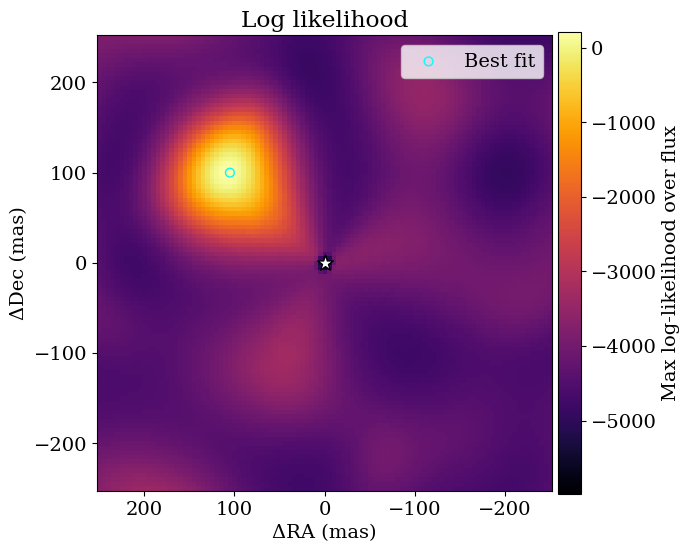

In [4]:
samples = {
    "dra": jnp.linspace(-250.0, 250.0, 101),
    "ddec": jnp.linspace(-250.0, 250.0, 101),
    "flux": 10 ** jnp.linspace(-4.0, -1.0, 31),
}
loglike = likelihood_grid(data, BinaryModelCartesian, samples)
best = best_grid_point(loglike, samples)
_ = plot_grid_map(loglike, samples, best=best, label="Max log-likelihood over flux")

### Least-squares fit

We then refine the best grid point:

In [5]:
start = System(
    primary=PointSource(),
    companion=PointSource(flux=best["flux"], dra=best["dra"], ddec=best["ddec"]),
)
priors = {
    "companion.dra": dist.Uniform(-300.0, 300.0),
    "companion.ddec": dist.Uniform(-300.0, 300.0),
    "companion.flux": dist.Uniform(0.0, 0.1),
}
result = fit(start, priors, data)
v = result.values
sep = np.hypot(v["companion.dra"], v["companion.ddec"])
pa = np.degrees(np.arctan2(v["companion.dra"], v["companion.ddec"])) % 360
dm = float(flux_to_delta_mag(v["companion.flux"]))
print(f"chi2_red = {result.info['chi2_red']:.2f}")
print(f"sep = {sep:.1f} mas, pa = {pa:.1f} deg, contrast = {dm:.2f} mag")

chi2_red = 1.07
sep = 147.1 mas, pa = 46.9 deg, contrast = 5.97 mag


If the calibrated errors look underestimated (reduced χ² ≫ 1), fit error
inflation terms with the model, e.g.
`fit(start, priors, data, noise={"phi_error": dist.HalfNormal(0.05)})`. For
posteriors sampled with HMC, see the
[virgil documentation](https://benjaminpope.github.io/virgil/).

### Contrast limits

For non-detections, we compute upper limits on the companion flux at the
3σ-equivalent percentile (Ruffio et al. 2018). For limits on a detected
system, subtract or fit the companion first.

/var/folders/19/fbthdtcx20d3xyc7y7vp_2v40000gn/T/ipykernel_29030/3555336021.py:1: RuntimeWarning: optimized_flux_grid(): the optimizer did not converge at 33 of 10201 grid positions; values there may be inaccurate.
  flux = optimized_flux_grid(data, BinaryModelCartesian, samples)


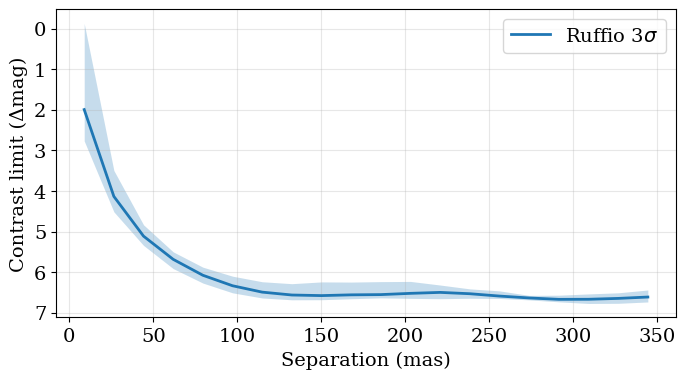

In [6]:
flux = optimized_flux_grid(data, BinaryModelCartesian, samples)
sigma_flux = laplace_flux_uncertainty_grid(
    data, BinaryModelCartesian, samples, flux=flux
)
limit = ruffio_upperlimit(flux, sigma_flux, norm.cdf(3.0))
_ = plot_contrast_curve(limit, samples, label=r"Ruffio 3$\sigma$")

## Legacy CANDID and Pymask functions

AMICAL's CANDID and Pymask functions keep their arguments and return values,
so existing scripts keep running, but the work is now done by virgil:

| function | what virgil computes |
|---|---|
| `amical.candid_grid` | likelihood grid of a companion around a uniform-disk primary, refined by least squares; uncertainties from the Fisher matrix |
| `amical.candid_cr_limit` | 3σ detection limits (Absil et al. 2011), after removing `fitComp` if given |
| `amical.pymask_grid` | χ² grid in separation, position angle and contrast ratio, closure phases only |
| `amical.pymask_mcmc` | posterior of the same binary, sampled with NUTS (HMC) instead of emcee |
| `amical.pymask_cr_limit` | 3σ contrast limits versus separation (Absil et al. 2011), closure phases only |

The results are close to, but not identical with, those of the original
packages. CANDID's "injection" limits and Pymask's Monte Carlo limits are
replaced by the Absil limits, and `nsim`, `walkers` and `ncore` are accepted
but ignored. virgil also accounts for the correlations between the
N(N-1)(N-2)/6 closure phases, so its uncertainties are larger than Pymask's
were (by about √(35/15) ≈ 1.5 for a 7-hole mask) and no `err_scale`
correction for the redundancy is needed. For new analyses, use virgil directly
as above. `amical.smartfit` is deprecated.

### CANDID-style companion search

`candid_grid` searches a grid of starting points from `rmin` to `rmax` (in
milliarcseconds), with step size `step`, and refines the best ones by least
squares. With `doNotFit=[]`, the diameter of the primary is fitted too. If you
want to save the figure locally as .pdf, use `save=True`.

In [7]:
param_candid = {
    "rmin": 20,  # inner radius of the grid
    "rmax": 250,  # outer radius of the grid
    "step": 50,  # grid sampling
}

 | --- Start CANDID-style fitting (virgil) --- :

Results binary fit (χ2 = 0.5, nσ = 12.9):
-------------------

Sep = 147.8 +/- 0.8 mas
Theta = 47.0 +/- 0.3 deg
CR = 250.4 +/- 2.3
dm = 6.00 +/- 0.01


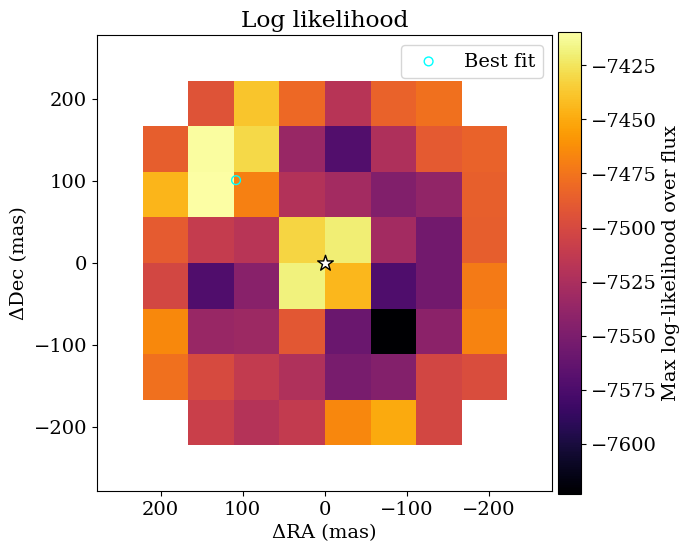

In [8]:
fit1 = amical.candid_grid(inputdata, **param_candid, diam=20, doNotFit=[], save=False)

Let us now take a look at the best-fit model compared to the data.

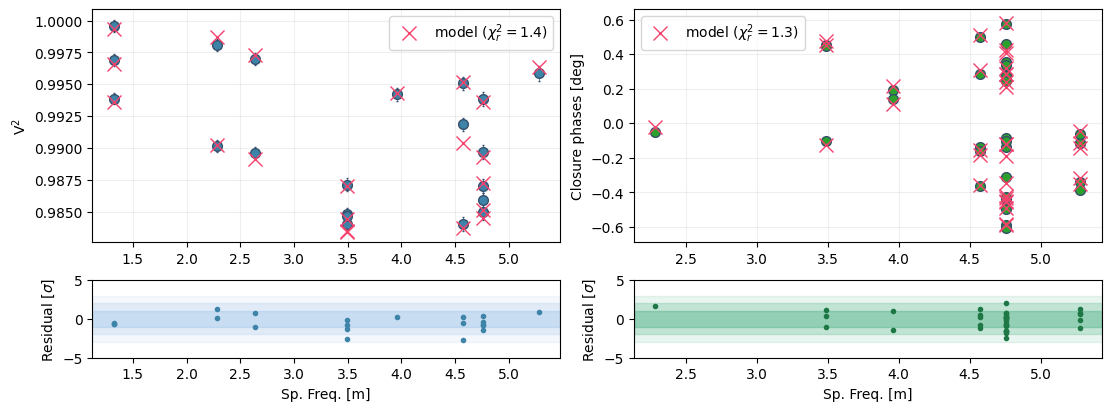

In [9]:
_ = amical.plot_model(inputdata, fit1["best"], save=False)

`candid_cr_limit` computes 3σ detection limits on a map around the
target, after removing the fitted companion from the data (`fitComp`).

 | --- Start CANDID-style contrast limit (virgil) --- :

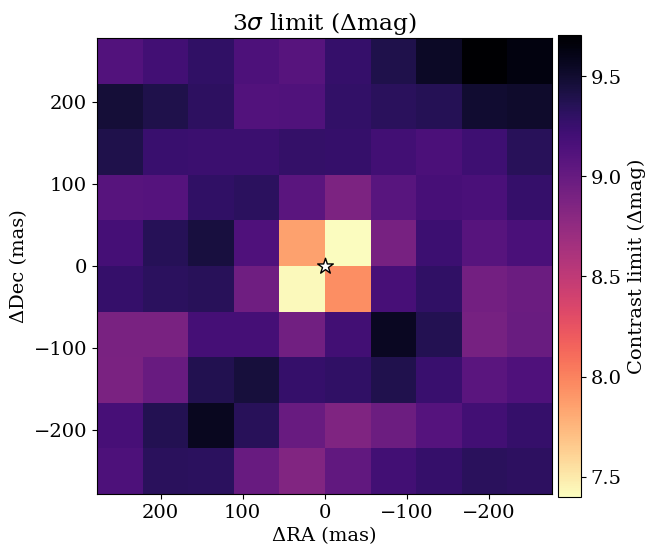

In [10]:
cr_candid = amical.candid_cr_limit(
    inputdata, **param_candid, fitComp=fit1["comp"], save=False
)

### Pymask-style inference

The Pymask functions use the closure phases only. They take priors in
separation, position angle and contrast ratio, and an optional additional
closure-phase uncertainty `extra_error_cp` (in degrees), which can account for
systematic errors, e.g. from a mismatch between the spectral types of the
calibrator and the science target, or from temporal variations, that the
calibrated uncertainties do not capture.

In [11]:
param_pymask = {
    "sep_prior": [100, 180],  # Prior on the separation
    "pa_prior": [20, 80],  # Prior on the position angle
    "cr_prior": [230, 270],  # Prior on the contrast ratio
    "extra_error_cp": 0,
}

`pymask_grid` computes the χ² over a grid of these parameters:

In [12]:
fit2 = amical.pymask_grid(inputdata, **param_pymask)


Maximum likelihood estimation (χ2=0.4):
-------------------------------
Separation = 147.18 mas
PA = 46.15 deg
Contrast Ratio = 246.4 (6.0 mag)



`pymask_mcmc` samples the posterior of the binary parameters with the
No-U-Turn Sampler (NUTS) of [numpyro](https://num.pyro.ai/), starting from an
initial guess (separation, position angle, contrast ratio):

  0%|          | 0/900 [00:00<?, ?it/s]

warmup:   5%|▌         | 45/900 [00:00<00:08, 100.51it/s, 23 steps of size 5.23e-02. acc. prob=0.75]

sample:  75%|███████▌  | 676/900 [00:00<00:00, 1602.42it/s, 7 steps of size 7.48e-01. acc. prob=0.92]

sample: 100%|██████████| 900/900 [00:00<00:00, 1551.43it/s, 7 steps of size 7.48e-01. acc. prob=0.92]

MCMC estimation
---------------
Separation = 147.1 +1.4/-1.2 mas
PA = 46.8 +0.5/-0.5 deg
Contrast Ratio = 246.7 +4.3/-4.3
dm = 5.98 +0.02/-0.02 mag


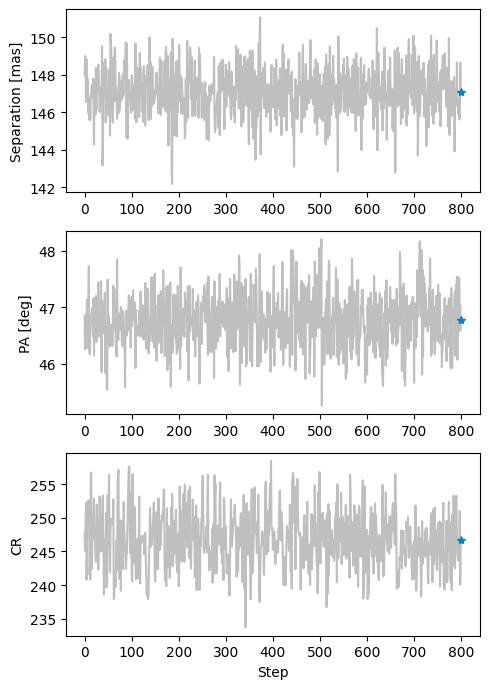

In [13]:
param_mcmc = {
    "niters": 800,
    "initial_guess": [146, 47, 244],
    "burn_in": 100,
}

fit3 = amical.pymask_mcmc(inputdata, **param_pymask, **param_mcmc)

`pymask_cr_limit` computes 3σ contrast limits versus separation, keeping
at each separation the limit valid at every position angle. Note that neither
these limits nor CANDID's are a substitute for end-to-end injection-recovery
simulations, which can probe biases and correlated noise.

In [14]:
cr_pymask = amical.pymask_cr_limit(inputdata, smax=250, nsep=100, cmax=5000, nth=30)

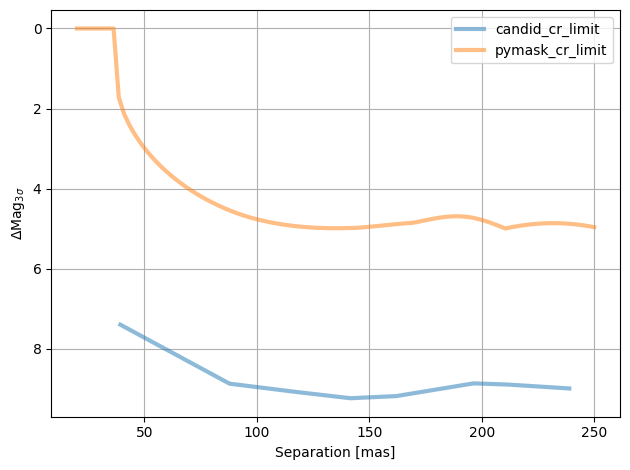

In [15]:
plt.figure()
plt.plot(
    cr_candid["r"], cr_candid["cr_limit"], label="candid_cr_limit", alpha=0.5, lw=3
)
plt.plot(
    cr_pymask["r"], cr_pymask["cr_limit"], label="pymask_cr_limit", alpha=0.5, lw=3
)
plt.ylim(plt.ylim()[1], plt.ylim()[0])  # -- reverse plot
plt.xlabel("Separation [mas]")
plt.ylabel(r"$\Delta \mathrm{Mag}_{3\sigma}$")
plt.legend(loc="best")
plt.grid()
plt.tight_layout()